# World Bank Commodity Price 

**หัวข้อโครงการ**: การสกัดข้อมูล (Scraping), การทำความสะอาด (Data Cleansing 3 เทคนิค), การจัดเก็บลงฐานข้อมูลเชิงสัมพันธ์แบบนอร์มัลไลซ์ (3NF & Star Schema) บน MySQL

## 0. เตรียมสภาพแวดล้อมและการนำเข้าโมดูล (Setup & Imports)


In [1]:
import os
import sys
import json
import logging
from datetime import datetime
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import pymysql
from sqlalchemy import create_engine

# กำหนดโฟลเดอร์สำหรับจัดเก็บข้อมูล
BASE_DIR = os.getcwd()
RAW_EXCEL_PATH = os.path.join(BASE_DIR, "data", "raw", "latest_monthly_prices.xlsx")
CLEAN_CSV_PATH = os.path.join(BASE_DIR, "data", "processed", "monthly_prices_cleaned.csv")
QUALITY_REPORT_PATH = os.path.join(BASE_DIR, "data", "processed", "quality_report.json")

os.makedirs(os.path.join(BASE_DIR, "data", "raw"), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, "data", "processed"), exist_ok=True)

print(f"Working Directory: {BASE_DIR}")
print(f"Pandas Version: {pd.__version__}")
print("Setup complete!")


Working Directory: c:\Users\Legion\Desktop\Day2_Homework\Project
Pandas Version: 2.3.0
Setup complete!


## 1. Step 1: Web Scraping จากเว็บไซต์ธนาคารโลก (World Bank Scraping)
- **URL**: `https://www.worldbank.org/en/research/commodity-markets`
- **Logic**: สแกนหาตารางในหัวข้อ "Recent Reports and Data" คอลัมน์ '"Pink Sheet" Data' และดึง URL จากแท็ก `<a>` ที่มีข้อความ "Monthly prices" จากนั้นดาวน์โหลดไฟล์มาบันทึกในโฟลเดอร์ `data/raw/`


In [2]:
from src.extract import get_monthly_prices_url, download_world_bank_data

# 1. ตรวจสอบการค้นหา URL ล่าสุดจากหน้าเว็บ World Bank
download_url = get_monthly_prices_url()
print(f"🎯 URL ดาวน์โหลดที่ค้นพบ: {download_url}")

# 2. ดาวน์โหลดไฟล์ Excel ข้อมูลราคาสินค้าโภคภัณฑ์รายเดือน
saved_file = download_world_bank_data(RAW_EXCEL_PATH)
file_size_kb = os.path.getsize(saved_file) / 1024
print(f"✅ บันทึกไฟล์เรียบร้อยที่: {saved_file} ({file_size_kb:.2f} KB)")


2026-09-05 14:41:37,230 [INFO] Navigating to Target URL: https://www.worldbank.org/en/research/commodity-markets
2026-09-05 14:41:37,432 [INFO] Found matching anchor tag with text: 'Monthly prices' -> https://thedocs.worldbank.org/en/doc/74e8be41ceb20fa0da750cda2f6b9e4e-0050012026/related/CMO-Historical-Data-Monthly.xlsx
2026-09-05 14:41:37,434 [INFO] Navigating to Target URL: https://www.worldbank.org/en/research/commodity-markets
2026-09-05 14:41:37,634 [INFO] Found matching anchor tag with text: 'Monthly prices' -> https://thedocs.worldbank.org/en/doc/74e8be41ceb20fa0da750cda2f6b9e4e-0050012026/related/CMO-Historical-Data-Monthly.xlsx


🎯 URL ดาวน์โหลดที่ค้นพบ: https://thedocs.worldbank.org/en/doc/74e8be41ceb20fa0da750cda2f6b9e4e-0050012026/related/CMO-Historical-Data-Monthly.xlsx


2026-09-05 14:41:37,635 [INFO] Starting download from: https://thedocs.worldbank.org/en/doc/74e8be41ceb20fa0da750cda2f6b9e4e-0050012026/related/CMO-Historical-Data-Monthly.xlsx
2026-09-05 14:41:37,743 [INFO] Download complete: c:\Users\Legion\Desktop\Day2_Homework\Project\data\raw\latest_monthly_prices.xlsx (572.98 KB)


✅ บันทึกไฟล์เรียบร้อยที่: c:\Users\Legion\Desktop\Day2_Homework\Project\data\raw\latest_monthly_prices.xlsx (572.98 KB)


## 2. Step 2: Data Cleansing & Transformation
ตอบโจทย์เกณฑ์การให้คะแนนอย่างครบถ้วน:
- **1.1 Cleansing เทคนิคที่ 1**: การจัดการค่าสูญหายและการแปลงชนิดข้อมูล
- **1.2 Cleansing เทคนิคที่ 2**: การปรับมาตรฐานข้อความและหัวตาราง
- **1.3 Cleansing เทคนิคที่ 3**: การปรับโครงสร้างข้อมูลจาก wide to long


In [3]:
# โหลดข้อมูล Raw จาก Sheet 'Monthly Prices'
df_raw = pd.read_excel(RAW_EXCEL_PATH, sheet_name="Monthly Prices", header=None)
print(f"มิติของข้อมูลดิบ (Raw Shape): {df_raw.shape}")

# -------------------------------------------------------------
# เทคนิคที่ 2: Text Normalization & Header Sanitization
# -------------------------------------------------------------
raw_comms = df_raw.iloc[4, 1:].tolist()
raw_units = df_raw.iloc[5, 1:].tolist()

# ลบสัญลักษณ์ดอกจัน (เช่น 'Coal, South African **' -> 'Coal, South African')
cleaned_comms = [str(c).replace("*", "").strip() for c in raw_comms]
# ปรับมาตรฐานหน่วยนับ ลบวงเล็บ (เช่น '($/bbl)' -> '$/bbl')
cleaned_units = [str(u).replace("(", "").replace(")", "").strip() if pd.notna(u) else "" for u in raw_units]
unit_map = dict(zip(cleaned_comms, cleaned_units))

# -------------------------------------------------------------
# เทคนิคที่ 1: จัดการข้อมูลสูญหายและแปลงชนิดข้อมูล (Date Parsing & Type Casting)
# -------------------------------------------------------------
df_data = df_raw.iloc[6:].copy()
df_data.columns = ["Date_Raw"] + cleaned_comms

# กรองเฉพาะแถวที่เป็นรูปแบบเดือน เช่น '1960M01'
date_filter = df_data["Date_Raw"].astype(str).str.match(r"^\d{4}M\d{2}$")
df_data = df_data[date_filter].copy()

# Parse วันที่เป็น DateTime ISO format
df_data["Date"] = pd.to_datetime(df_data["Date_Raw"].astype(str).str.replace("M", "-"), format="%Y-%m")

# -------------------------------------------------------------
# เทคนิคที่ 3: Data Reshape (Melt) & Metadata Integration
# -------------------------------------------------------------
# Unpivot จาก Wide Table (71 คอลัมน์) -> Long Format
melted = df_data.melt(id_vars=["Date"], value_vars=cleaned_comms, var_name="Commodity", value_name="Price_Raw")

# แปลงราคาเป็น Numeric และจัดการ Missing Values
melted["Price"] = pd.to_numeric(melted["Price_Raw"], errors="coerce")

# แมปกลุ่มสินค้า (Group_Product)
def classify_group(comm):
    c = comm.lower()
    if any(x in c for x in ["oil", "coal", "gas"]): return "Energy"
    if any(x in c for x in ["cocoa", "coffee", "tea"]): return "Beverages"
    if any(x in c for x in ["meal", "soybean", "groundnut", "palm", "sunflower", "rapeseed"]): return "Oils and Meals"
    if any(x in c for x in ["wheat", "rice", "maize", "barley", "sorghum"]): return "Grains"
    if any(x in c for x in ["banana", "orange", "beef", "chicken", "lamb", "shrimp", "sugar"]): return "Other food"
    if any(x in c for x in ["tobacco", "log", "sawnwood", "plywood", "cotton", "rubber"]): return "Other Raw Materials"
    if any(x in c for x in ["phosphate", "dap", "tsp", "urea", "potassium"]): return "Fertilizers"
    if any(x in c for x in ["gold", "platinum", "silver"]): return "Precious Metals"
    return "Metals and Minerals"

melted["Group_Product"] = melted["Commodity"].apply(classify_group)
melted["Unit"] = melted["Commodity"].map(unit_map)
melted["Source"] = "World Bank Commodity Markets"
melted["Description"] = melted["Commodity"] + " monthly nominal price"

final_columns = ["Date", "Commodity", "Group_Product", "Description", "Source", "Unit", "Price"]
clean_df = melted[final_columns].sort_values(by=["Date", "Commodity"]).reset_index(drop=True)

# บันทึกเป็น CSV
clean_df.to_csv(CLEAN_CSV_PATH, index=False)
print(f"✅ ทำความสะอาดเสร็จสมบูรณ์: {len(clean_df):,} แถว (ครอบคลุม 71 สินค้าโภคภัณฑ์)")
clean_df.head(10)


มิติของข้อมูลดิบ (Raw Shape): (806, 72)
✅ ทำความสะอาดเสร็จสมบูรณ์: 56,800 แถว (ครอบคลุม 71 สินค้าโภคภัณฑ์)


,Date,Commodity,Group_Product,Description,Source,Unit,Price
0,1960-01-01,Aluminum,Metals and Minerals,Aluminum monthly nominal price,World Bank Commodity Markets,$/mt,511.00
1,1960-01-01,"Banana, Europe",Other food,"Banana, Europe monthly nominal price",World Bank Commodity Markets,$/kg,NaN
2,1960-01-01,"Banana, US",Other food,"Banana, US monthly nominal price",World Bank Commodity Markets,$/kg,0.14
3,1960-01-01,Barley,Grains,Barley monthly nominal price,World Bank Commodity Markets,$/mt,20.40
4,1960-01-01,Beef,Other food,Beef monthly nominal price,World Bank Commodity Markets,$/kg,0.71
5,1960-01-01,Chicken,Other food,Chicken monthly nominal price,World Bank Commodity Markets,$/kg,0.30
6,1960-01-01,"Coal, Australian",Energy,"Coal, Australian monthly nominal price",World Bank Commodity Markets,$/mt,NaN
7,1960-01-01,"Coal, South African",Energy,"Coal, South African monthly nominal price",World Bank Commodity Markets,$/mt,NaN
8,1960-01-01,Cocoa,Beverages,Cocoa monthly nominal price,World Bank Commodity Markets,$/kg,0.63
9,1960-01-01,Coconut oil,Energy,Coconut oil monthly nominal price,World Bank Commodity Markets,$/mt,390.00


## 3. Step 3: Quality Report

In [ ]:
# 1. กำหนด Master List ของสินค้าโภคภัณฑ์ที่รู้จัก (ดึงจาก cleaned_comms ใน Step 2)
known_commodities = set(cleaned_comms)
flag_cols = [] 

df = clean_df.copy()

# 2. สร้าง Flag ตรวจสอบข้อมูลแต่ละมิติ
df["is_duplicate"] = df.duplicated(subset=["Date", "Commodity"], keep="first")
df["invalid_date"] = df["Date"].isna()
df["missing_commodity"] = df["Commodity"].isna() | (df["Commodity"].astype("string").str.strip() == "")
df["unknown_commodity"] = ~df["Commodity"].isin(known_commodities) & ~df["missing_commodity"]
df["missing_price"] = df["Price"].isna()
df["negative_price"] = df["Price"] < 0
df["outlier_price"] = df["Price"] > 100000
# 3. รวบรวม flag ทั้งหมด
flag_cols = [
    "is_duplicate",
    "invalid_date",
    "missing_commodity",
    "unknown_commodity",
    "missing_price",
    "negative_price",
    "outlier_price"
]

# 4. .any(axis=1) ตรวจว่าในแต่ละแถวมีค่า True อย่างน้อย 1 ตัวหรือไม่
df["is_valid"] = ~df[flag_cols].any(axis=1)

# 5. แสดงตัวอย่างผลลัพธ์
display_cols = ["Date", "Commodity", "Group_Product", "Unit", "Price"] + flag_cols + ["is_valid"]
print(f"📊 ตรวจสอบข้อมูลทั้งหมด: {len(df):,} แถว")
print(f"✅ ข้อมูลที่สมบูรณ์พร้อมใช้ (Valid): {df['is_valid'].sum():,} แถว ({df['is_valid'].mean()*100:.2f}%)")
print(f"⚠️ ข้อมูลที่มี Flag ตรวจพบ (Invalid): {(~df['is_valid']).sum():,} แถว ({(~df['is_valid']).mean()*100:.2f}%)")
print("\n📋 สรุปจำนวน Error รายข้อ:")
for col in flag_cols:
    print(f"  - {col}: {df[col].sum():,} แถว")


📊 ตรวจสอบข้อมูลทั้งหมด: 56,800 แถว
✅ ข้อมูลที่สมบูรณ์พร้อมใช้ (Valid): 50,383 แถว (88.70%)
⚠️ ข้อมูลที่มี Flag ตรวจพบ (Invalid): 6,417 แถว (11.30%)

📋 สรุปจำนวน Error รายข้อ:
  - is_duplicate: 0 แถว
  - invalid_date: 0 แถว
  - missing_commodity: 0 แถว
  - unknown_commodity: 0 แถว
  - missing_price: 6,417 แถว
  - negative_price: 0 แถว
  - outlier_price: 0 แถว


## 4. Step 4: Vizualization

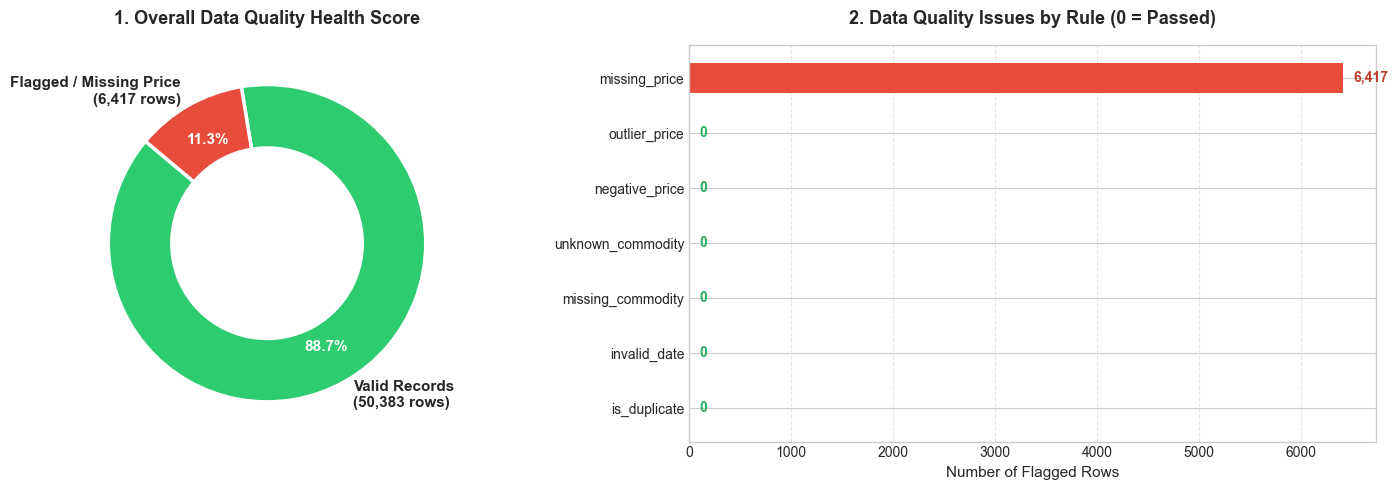

C:\Users\Legion\AppData\Local\Temp\ipykernel_12628\1219017205.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_stat, x="missing_pct", y="Group_Product", ax=axes[0], palette="YlOrRd_r")


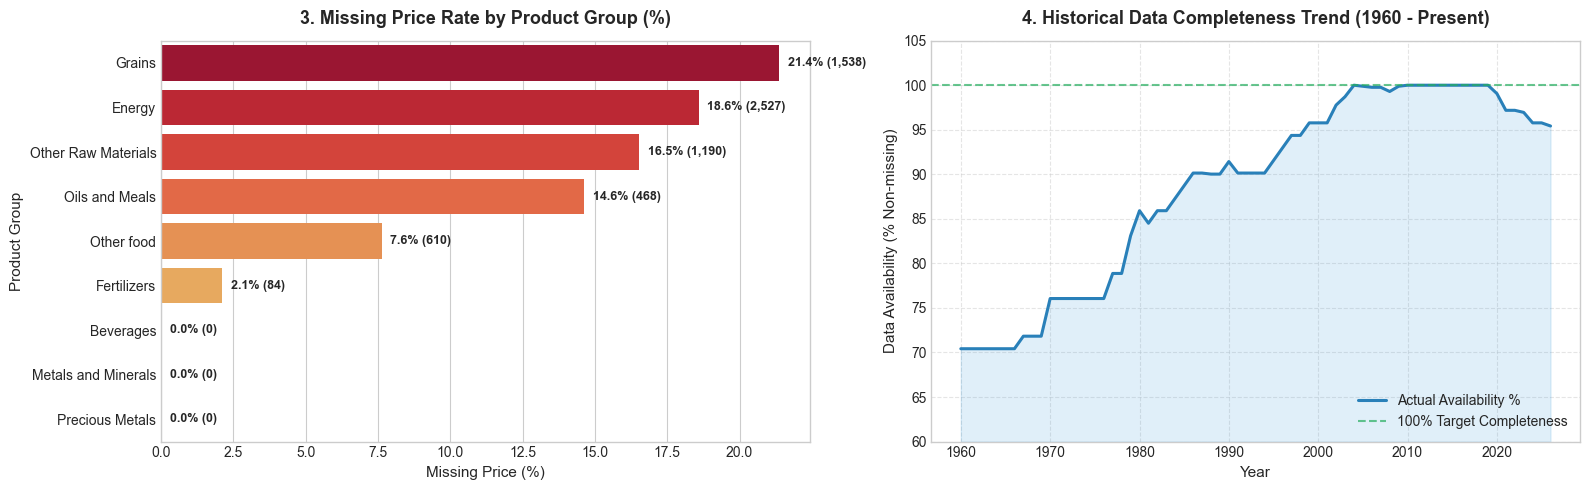

In [ ]:
# ลง library matplotlib และ seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Clean, professional modern style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


# ภาพเซ็ต 1 : สร้าง Figure และ Subplot จำนวน 2 ภาพเรีรยงตามแนวนอน
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart 1: Donut Chart - Valid vs Flagged Records
valid_cnt = df["is_valid"].sum()
invalid_cnt = (~df["is_valid"]).sum()
labels = [f"Valid Records\n({valid_cnt:,} rows)", f"Flagged / Missing Price\n({invalid_cnt:,} rows)"]
colors = ["#2ecc71", "#e74c3c"]

wedges, texts, autotexts = axes[0].pie(
    [valid_cnt, invalid_cnt],
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    pctdistance=0.75,
    textprops={"fontsize": 11, "fontweight": "bold"},
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2.5)
)
for at in autotexts:
    at.set_color("white")
axes[0].set_title("1. Overall Data Quality Health Score", fontsize=13, fontweight="bold", pad=15)

# Chart 2: Horizontal Bar - Issue Breakdown by Rule
flag_summary = df[flag_cols].sum().reset_index()
flag_summary.columns = ["Rule", "Count"]
flag_summary = flag_summary.sort_values(by="Count", ascending=True)

bar_colors = ["#e74c3c" if c > 0 else "#27ae60" for c in flag_summary["Count"]]
bars = axes[1].barh(flag_summary["Rule"], flag_summary["Count"], color=bar_colors, height=0.55)
axes[1].set_title("2. Data Quality Issues by Rule (0 = Passed)", fontsize=13, fontweight="bold", pad=15)
axes[1].set_xlabel("Number of Flagged Rows", fontsize=11)
axes[1].grid(axis="x", linestyle="--", alpha=0.5)

# Label values at the end of each bar
for bar in bars:
    w = bar.get_width()
    axes[1].text(w + 100, bar.get_y() + bar.get_height()/2, f"{int(w):,}",
                 va="center", ha="left", fontsize=10, fontweight="bold",
                 color="#c0392b" if w > 0 else "#27ae60")

plt.tight_layout()
plt.show()


# ภาพเซ็ต 2 : Missing Price  by Category & Timeline

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 3: Missing Price % by Product Group
group_stat = df.groupby("Group_Product")["missing_price"].agg(total="count", missing="sum").reset_index()
group_stat["missing_pct"] = (group_stat["missing"] / group_stat["total"]) * 100
group_stat = group_stat.sort_values(by="missing_pct", ascending=False)

sns.barplot(data=group_stat, x="missing_pct", y="Group_Product", ax=axes[0], palette="YlOrRd_r")
axes[0].set_title("3. Missing Price Rate by Product Group (%)", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlabel("Missing Price (%)", fontsize=11)
axes[0].set_ylabel("Product Group", fontsize=11)
for i, row in group_stat.reset_index(drop=True).iterrows():
    axes[0].text(row["missing_pct"] + 0.3, i, f"{row['missing_pct']:.1f}% ({row['missing']:,})",
                 va="center", fontsize=9, fontweight="bold")

# Chart 4: Historical Completeness Trend (1960 - Present)
df["Year"] = pd.to_datetime(df["Date"]).dt.year
yearly_avail = df.groupby("Year")["Price"].apply(lambda x: (x.notna().mean()) * 100).reset_index()

axes[1].plot(yearly_avail["Year"], yearly_avail["Price"], color="#2980b9", linewidth=2.2, label="Actual Availability %")
axes[1].fill_between(yearly_avail["Year"], yearly_avail["Price"], 60, color="#3498db", alpha=0.15)
axes[1].set_title("4. Historical Data Completeness Trend (1960 - Present)", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlabel("Year", fontsize=11)
axes[1].set_ylabel("Data Availability (% Non-missing)", fontsize=11)
axes[1].set_ylim(60, 105)
axes[1].axhline(100, color="#27ae60", linestyle="--", alpha=0.7, label="100% Target Completeness")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


## 5. Step 5: Database
- **2.1 เลือกใช้ Relational Database**:
  - ข้อมูลราคาสินค้าโภคภัณฑ์เป็นข้อมูล Time-Series แบบตารางที่มี Schema ชัดเจนแน่นอน
  - มีความสัมพันธ์เชิงโครงสร้างที่เหมาะสมต่อการแยกตาราง Dimension (`dim_commodity`) และ Fact (`fact_monthly_prices`) ตามหลักการ **3rd Normal Form (3NF)** และ **Star Schema** เพื่อลดความซ้ำซ้อนของข้อมูลอธิบาย

- **2.2 การออกแบบโครงสร้างและการจัดเก็บ**:
  - `dim_commodity`: Dimension Table (3NF)
  - `fact_monthly_prices`: Fact Table (3NF)
  - `monthly_prices`: Denormalized Table ตามข้อกำหนด Step 3 ของโจทย์
  - ใช้วิธีการโหลดข้อมูลแบบ **Idempotent Batch Upsert (`ON DUPLICATE KEY UPDATE`)**


In [ ]:
from src.database import init_database_and_tables, load_data_to_mysql

# เริ่มต้นสร้างฐานข้อมูลและตาราง
init_database_and_tables()

# ดำเนินการ Ingest ข้อมูลเข้าสู่ MySQL แบบ Idempotent
load_data_to_mysql(clean_df)

# ตรวจสอบจำนวนแถวในแต่ละตารางผ่าน SQLAlchemy
engine = create_engine("mysql+pymysql://root:@127.0.0.1:3306/world_bank?charset=utf8mb4")

with engine.connect() as conn:
    dim_count = conn.execute(pd.io.sql.text("SELECT COUNT(*) FROM dim_commodity;")).scalar()
    fact_count = conn.execute(pd.io.sql.text("SELECT COUNT(*) FROM fact_monthly_prices;")).scalar()
    monthly_count = conn.execute(pd.io.sql.text("SELECT COUNT(*) FROM monthly_prices;")).scalar()

print(f"📊 สรุปข้อมูลที่ถูกบันทึกลงใน MySQL (Schema: world_bank):")
print(f"• ตาราง Dimension (dim_commodity): {dim_count} รายการ")
print(f"• ตาราง Fact (fact_monthly_prices): {fact_count:,} แถว")
print(f"• ตาราง Denormalized (monthly_prices): {monthly_count:,} แถว")
